In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading a dataset
df = pd.read_csv('ecommerce.csv')
df.head()

,OrderID,CustomerID,ProductCategory,ProductPrice,Quantity,DiscountPercent,PaymentMethod,OrderStatus,City,OrderDate,TotalAmount,DiscountAmount,FinalAmount,Month,Year
0,100001,4174,Beauty,2036,3,5,Debit Card,Delivered,Pune,2023-01-01,6108,305.4,5802.6,1,2023
1,100002,4507,Sports,4456,3,20,Cash,Cancelled,Mumbai,2023-01-02,13368,2673.6,10694.4,1,2023
2,100003,1860,Beauty,2648,4,0,Debit Card,Delivered,Chennai,2023-01-03,10592,0.0,10592.0,1,2023
3,100004,2294,Sports,4493,2,0,Debit Card,Delivered,Mumbai,2023-01-04,8986,0.0,8986.0,1,2023
4,100005,2130,Sports,1483,9,10,Debit Card,Cancelled,Chennai,2023-01-05,13347,1334.7,12012.3,1,2023


In [3]:
# ensure OrderDate is parsed as pandas datetime (ns precision) and cast numeric columns to float
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')
df = df.astype({
    'DiscountPercent': 'float64',
    'TotalAmount': 'float64'
})
df.info()

# error = coerce will replace invalid parsing with NaT


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   OrderID           1500 non-null   int64         
 1   CustomerID        1500 non-null   int64         
 2    ProductCategory  1500 non-null   object        
 3    ProductPrice     1500 non-null   int64         
 4   Quantity          1500 non-null   int64         
 5   DiscountPercent   1500 non-null   float64       
 6   PaymentMethod     1500 non-null   object        
 7   OrderStatus       1500 non-null   object        
 8   City              1500 non-null   object        
 9   OrderDate         1500 non-null   datetime64[ns]
 10  TotalAmount       1500 non-null   float64       
 11  DiscountAmount    1500 non-null   float64       
 12  FinalAmount       1500 non-null   float64       
 13  Month             1500 non-null   int64         
 14  Year              1500 n

In [4]:
df.describe()

,OrderID,CustomerID,ProductPrice,Quantity,DiscountPercent,OrderDate,TotalAmount,DiscountAmount,FinalAmount,Month,Year
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,100750.500000,3004.632667,2648.915333,5.082667,9.926667,2025-01-19 12:00:00,13262.911333,1305.879133,11957.032200,6.384667,2024.564667
min,100001.000000,1001.000000,206.000000,1.000000,0.000000,2023-01-01 00:00:00,315.000000,0.000000,299.250000,1.000000,2023.000000
25%,100375.750000,2050.500000,1508.500000,3.000000,5.000000,2024-01-10 18:00:00,4844.750000,179.237500,4270.575000,3.000000,2024.000000
50%,100750.500000,2981.500000,2649.000000,5.000000,10.000000,2025-01-19 12:00:00,10665.000000,782.150000,9772.000000,6.000000,2025.000000
75%,101125.250000,3965.250000,3844.000000,7.000000,15.000000,2026-01-29 06:00:00,19035.000000,1853.600000,17086.087500,9.000000,2026.000000
max,101500.000000,4994.000000,4999.000000,9.000000,20.000000,2027-02-08 00:00:00,44514.000000,8542.800000,44514.000000,12.000000,2027.000000
std,433.157015,1131.631818,1364.872212,2.551112,7.113018,NaN,10116.736365,1525.310814,9233.524611,3.508975,1.173060


In [5]:
# chacking for missing values
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False) 

OrderID             0.0
CustomerID          0.0
 ProductCategory    0.0
 ProductPrice       0.0
Quantity            0.0
DiscountPercent     0.0
PaymentMethod       0.0
OrderStatus         0.0
City                0.0
OrderDate           0.0
TotalAmount         0.0
DiscountAmount      0.0
FinalAmount         0.0
Month               0.0
Year                0.0
dtype: float64

In [6]:
df.columns

Index(['OrderID', 'CustomerID', ' ProductCategory', ' ProductPrice',
       'Quantity', 'DiscountPercent', 'PaymentMethod', 'OrderStatus', 'City',
       'OrderDate', 'TotalAmount', 'DiscountAmount', 'FinalAmount', 'Month',
       'Year'],
      dtype='object')

In [7]:
df.columns = df.columns.str.strip()
df.columns

Index(['OrderID', 'CustomerID', 'ProductCategory', 'ProductPrice', 'Quantity',
       'DiscountPercent', 'PaymentMethod', 'OrderStatus', 'City', 'OrderDate',
       'TotalAmount', 'DiscountAmount', 'FinalAmount', 'Month', 'Year'],
      dtype='object')

In [8]:
df.shape

(1500, 15)

### 1. UNIVARIATE ANALYSIS 

#### A) Numerical Univariate

Non-visual

In [9]:
#We will check for unreal value , mean and midean (to identify skewness) and statistical summary of numerical columns

In [10]:
# Statistic summary of numeric columns
df.describe()

,OrderID,CustomerID,ProductPrice,Quantity,DiscountPercent,OrderDate,TotalAmount,DiscountAmount,FinalAmount,Month,Year
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,100750.500000,3004.632667,2648.915333,5.082667,9.926667,2025-01-19 12:00:00,13262.911333,1305.879133,11957.032200,6.384667,2024.564667
min,100001.000000,1001.000000,206.000000,1.000000,0.000000,2023-01-01 00:00:00,315.000000,0.000000,299.250000,1.000000,2023.000000
25%,100375.750000,2050.500000,1508.500000,3.000000,5.000000,2024-01-10 18:00:00,4844.750000,179.237500,4270.575000,3.000000,2024.000000
50%,100750.500000,2981.500000,2649.000000,5.000000,10.000000,2025-01-19 12:00:00,10665.000000,782.150000,9772.000000,6.000000,2025.000000
75%,101125.250000,3965.250000,3844.000000,7.000000,15.000000,2026-01-29 06:00:00,19035.000000,1853.600000,17086.087500,9.000000,2026.000000
max,101500.000000,4994.000000,4999.000000,9.000000,20.000000,2027-02-08 00:00:00,44514.000000,8542.800000,44514.000000,12.000000,2027.000000
std,433.157015,1131.631818,1364.872212,2.551112,7.113018,NaN,10116.736365,1525.310814,9233.524611,3.508975,1.173060


##### 🔸Visual

In [11]:
# We will create histogram (to check data distribution) and boxplot (to find outliers) of important columns like 'TotalAmount' and 'DiscountPercent'

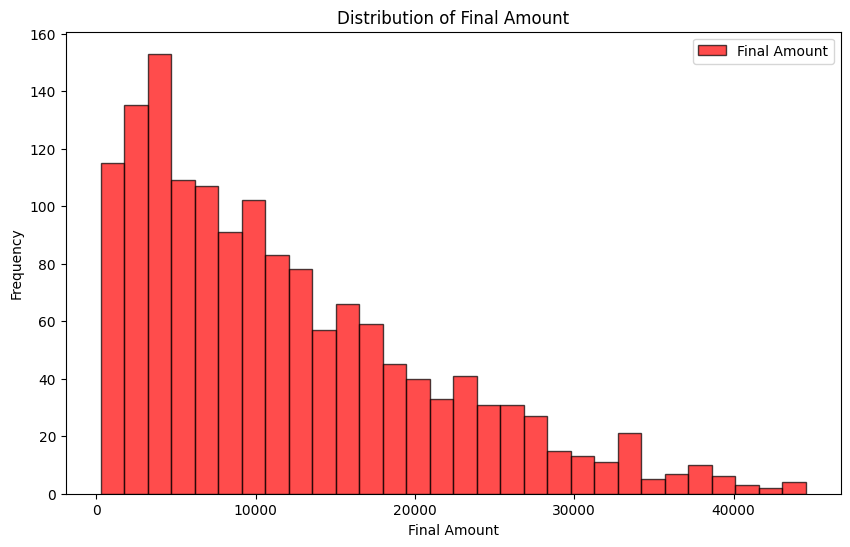

In [12]:
#histogram
# Histogram of 'FinalAmount'
plt.figure(figsize=(10,6))
plt.hist(df['FinalAmount'], bins=30, color='Red', alpha=0.7, edgecolor='black', label='Final Amount')
plt.title('Distribution of Final Amount')
plt.xlabel('Final Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [13]:
#This histogram shows the distribution of the FinalAmount values across the dataset.
#  Most values are concentrated in specific ranges, indicating where the data is densely populated,
#  while fewer values at the extremes represent rare or high/low amounts.
#  Overall, the graph helps identify the spread and skewness of the FinalAmount data.


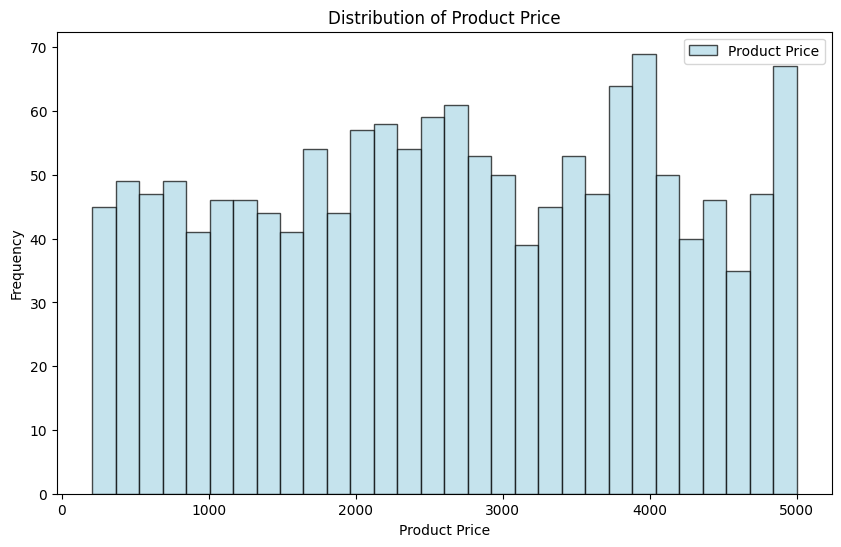

In [14]:
#histogram
# Histogram of 'ProductPrice'
plt.figure(figsize=(10,6))
plt.hist(df['ProductPrice'], bins=30, color='lightblue', alpha=0.7, edgecolor='black', label='Product Price')
plt.title('Distribution of Product Price')
plt.xlabel('Product Price')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [15]:
#This histogram represents the distribution of ProductPrice values in the dataset.
#Most products fall within a common price range, showing where prices are concentrated.
#The spread of the bars helps identify price variation and possible outliers.

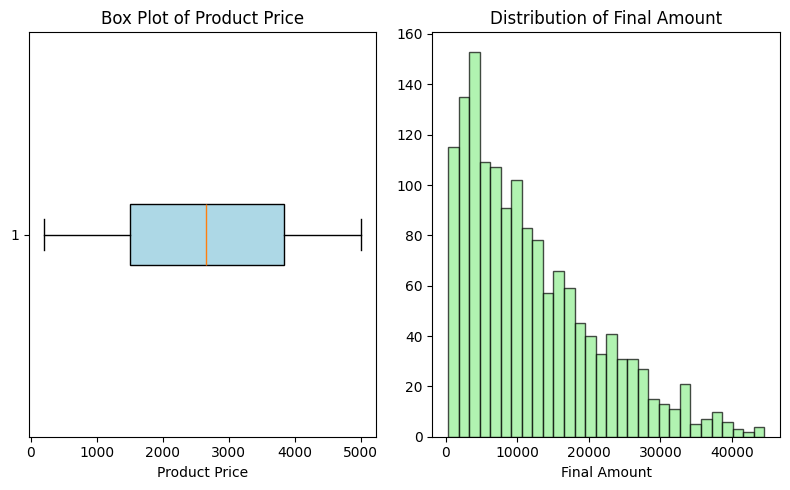

In [16]:
#Box plot
# Box plot of 'ProductPrice' and histogram of 'FinalAmount'
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.boxplot(df['ProductPrice'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Product Price')
plt.xlabel('Product Price')


plt.subplot(1,2,2)
plt.hist(df['FinalAmount'], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
plt.title('Distribution of Final Amount')
plt.xlabel('Final Amount')
plt.tight_layout()
plt.show()

In [17]:
#The box plot of ProductPrice shows the median, spread, and potential outliers in product prices.

#The histogram of FinalAmount displays how final transaction amounts are distributed across different ranges.

#Together, these plots help compare price variability with overall purchase amount distribution.

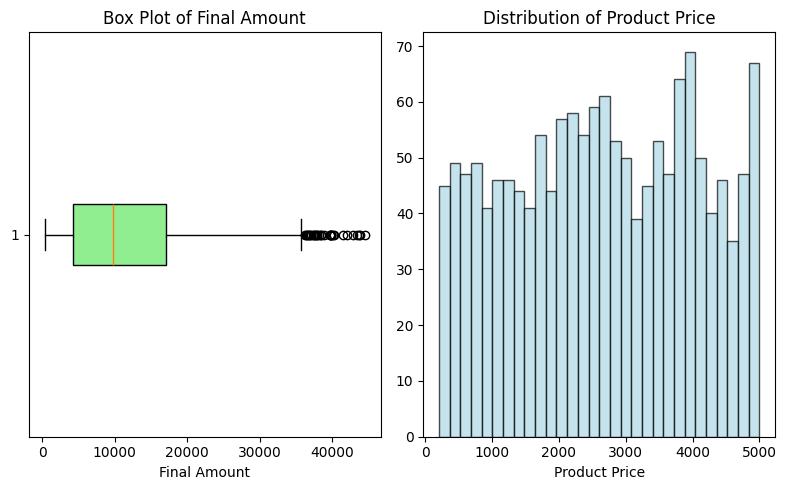

In [18]:
#box plot
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.boxplot(df['FinalAmount'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title('Box Plot of Final Amount')
plt.xlabel('Final Amount')

plt.subplot(1,2,2)
plt.hist(df['ProductPrice'], bins=30, color='lightblue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Product Price')
plt.xlabel('Product Price')
plt.tight_layout()
plt.show()

In [19]:
#The box plot of FinalAmount highlights the median value, spread, and any potential outliers in the final amounts.
#The histogram of ProductPrice shows how product prices are distributed across different ranges.
#These plots together help understand variability in final amounts compared to individual product prices.


#### B) Categorical Univariate

##### 🔸Non-visual

In [20]:
#frequency distribution of Order Status
print("Frequency Distribution of Order Status:")
print(df['OrderStatus'].value_counts())

print("\nPercentage Distribution of Order Status:")
print(df['OrderStatus'].value_counts(normalize=True) * 100)

print("\n Order Status Distribution:")
print(df['OrderStatus'].nunique())

Frequency Distribution of Order Status:
OrderStatus
Delivered    532
Cancelled    502
Returned     466
Name: count, dtype: int64

Percentage Distribution of Order Status:
OrderStatus
Delivered    35.466667
Cancelled    33.466667
Returned     31.066667
Name: proportion, dtype: float64

 Order Status Distribution:
3


##### 🔸Visual

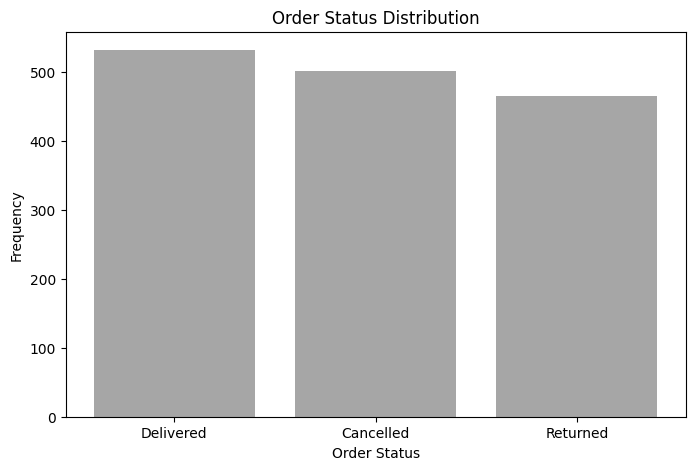

In [21]:
# barchart
plt.figure(figsize=(8,5))
plt.bar(df['OrderStatus'].value_counts().index, df['OrderStatus'].value_counts().values, color='gray', alpha=0.7)
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Frequency')
plt.show()

In [22]:
#This bar chart displays the frequency of each OrderStatus category in the dataset.
#It shows which order statuses occur most often and which are less common.
#The chart helps quickly compare order outcomes and overall order flow.

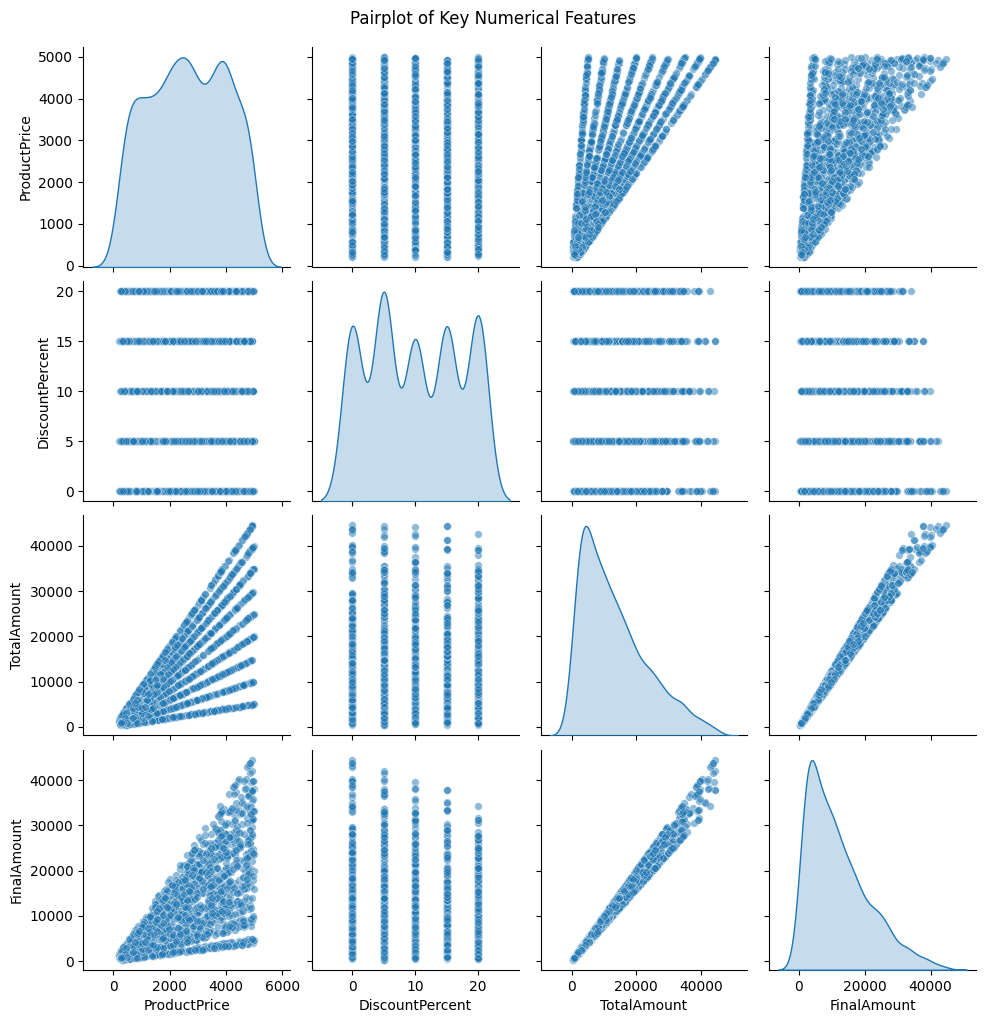

In [50]:
sns.pairplot(df[['ProductPrice', 'DiscountPercent', 'TotalAmount', 'FinalAmount']], diag_kind='kde', plot_kws={'alpha':0.5, 's':30,})
plt.suptitle('Pairplot of Key Numerical Features', y=1.02)
plt.show()


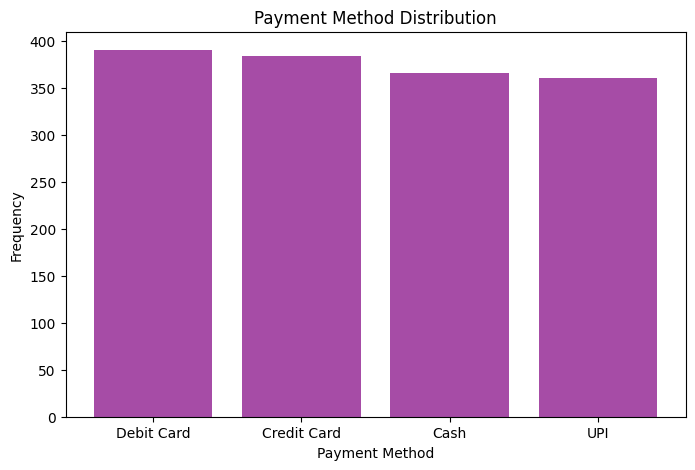

In [23]:
#barchart
plt.figure(figsize=(8,5))
plt.bar(df['PaymentMethod'].value_counts().index, df['PaymentMethod'].value_counts().values, color='purple', alpha=0.7)
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Frequency')
plt.show()

In [24]:
#This bar chart represents the frequency of different PaymentMethod types used by customers.
#It highlights the most preferred and least used payment methods.
#The chart helps understand customer payment behavior and preferences.

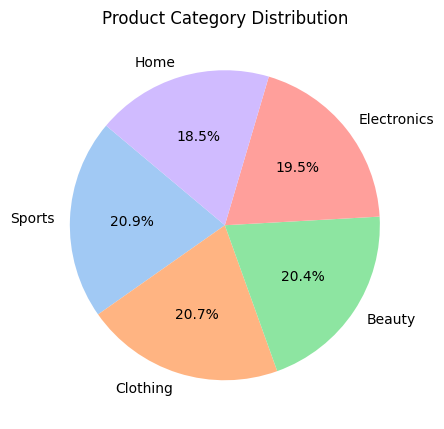

In [25]:
#pie chart
plt.figure(figsize=(5,6))
plt.pie(df['ProductCategory'].value_counts().values, labels=df['ProductCategory'].value_counts().index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Product Category Distribution')
plt.show()

In [26]:
#This pie chart shows the percentage distribution of different ProductCategory values.
#Each slice represents the contribution of a category to total products or orders.
#It helps quickly identify the most and least popular product categories.

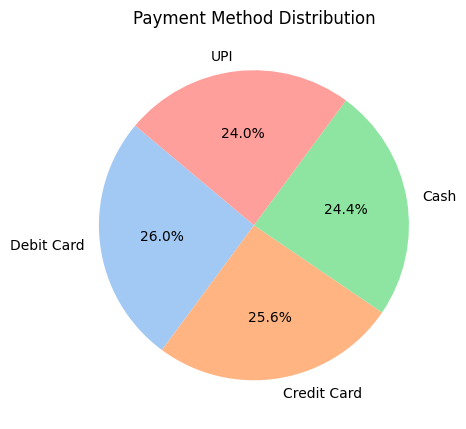

In [27]:
#pie chart
plt.figure(figsize=(5,6))
plt.pie(df['PaymentMethod'].value_counts().values, labels=df['PaymentMethod'].value_counts().index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Payment Method Distribution')
plt.show()

In [28]:
#This pie chart illustrates the percentage share of each PaymentMethod used in transactions.
#It clearly shows which payment methods are most and least preferred by customers.
#The chart helps in understanding overall payment trends at a glance.

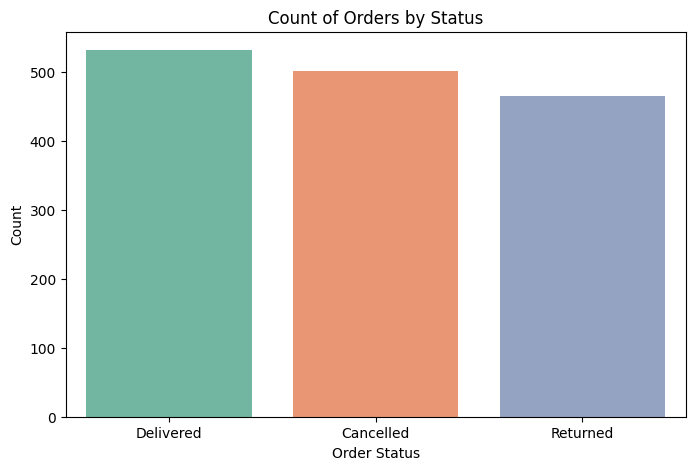

In [29]:
#countplot

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='OrderStatus', hue='OrderStatus', palette='Set2')
plt.title('Count of Orders by Status')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.show()

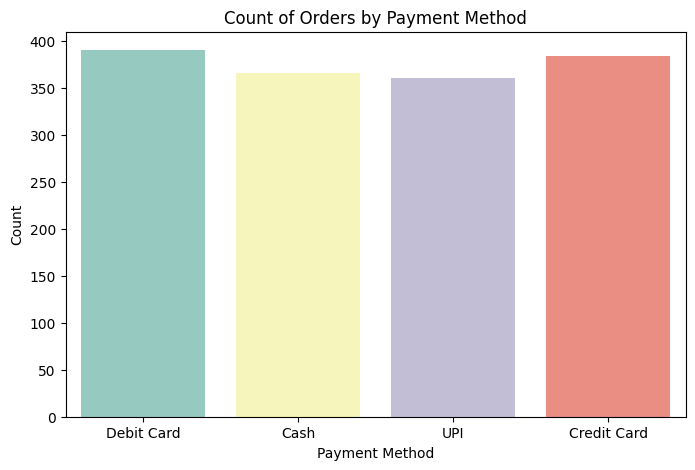

In [30]:
#countplot

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='PaymentMethod', hue='PaymentMethod', palette='Set3')
plt.title('Count of Orders by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

### 2. BIVARIATE ANALYSIS (Two columns together)

#### A) Numerical vs Numerical

##### 🔸Non-Visual

In [31]:
#correlation 
df[['ProductPrice', 'FinalAmount']].corr()

,ProductPrice,FinalAmount
ProductPrice,1.000000,0.658385
FinalAmount,0.658385,1.000000


In [32]:
#covariance
df[['ProductPrice', 'FinalAmount']].cov()

,ProductPrice,FinalAmount
ProductPrice,1.862876e+06,8.297352e+06
FinalAmount,8.297352e+06,8.525798e+07


##### 🔸Visual

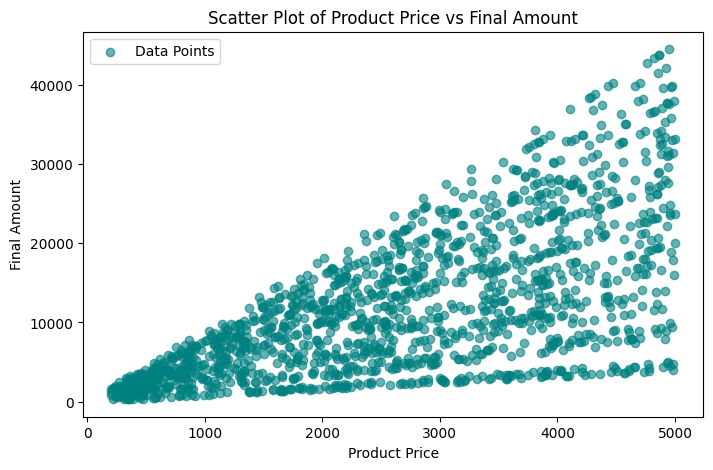

In [33]:
#scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df['ProductPrice'], df['FinalAmount'], alpha=0.6, color='teal', label='Data Points')
plt.title('Scatter Plot of Product Price vs Final Amount')
plt.xlabel('Product Price')
plt.ylabel('Final Amount')
plt.legend()
plt.show()

In [34]:
#This scatter plot shows the relationship between ProductPrice and FinalAmount.
#Each point represents an order, helping visualize trends or correlations between the two variables.
#The spread of points indicates variability and possible patterns in pricing and final amounts.

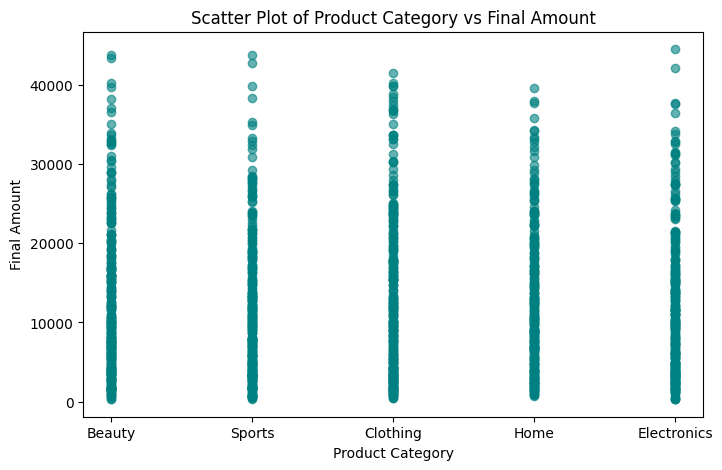

In [35]:
#scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df['ProductCategory'], df['FinalAmount'], alpha=0.6, color='teal')
plt.title('Scatter Plot of Product Category vs Final Amount')
plt.xlabel('Product Category')
plt.ylabel('Final Amount')
plt.show()

In [36]:
#This scatter plot shows how FinalAmount varies across different ProductCategory values.
#Each point represents an order, helping compare spending patterns among categories.
#The distribution of points highlights categories with higher or more variable final amounts.

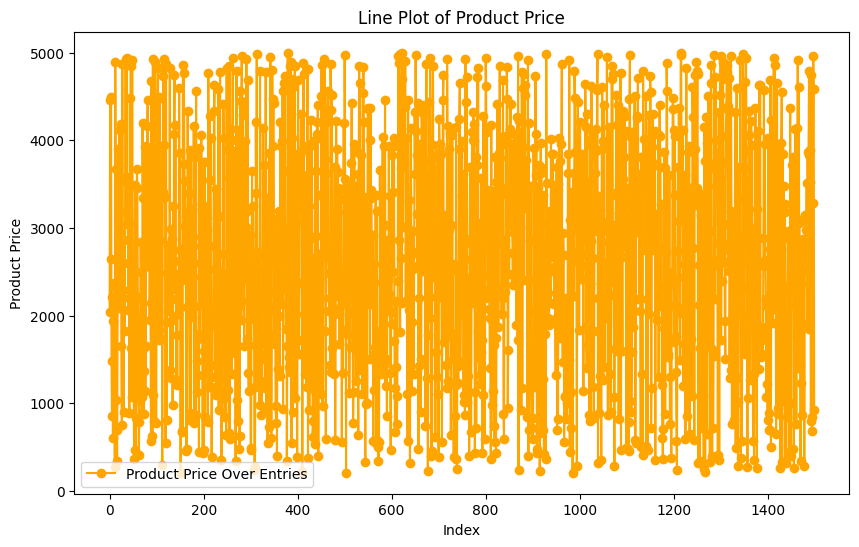

In [37]:
#line plot
plt.figure(figsize=(10,6))
plt.plot(df['ProductPrice'], color='orange', marker='o', label='Product Price Over Entries')
plt.title('Line Plot of Product Price')
plt.xlabel('Index')
plt.ylabel('Product Price')
plt.legend()
plt.show()

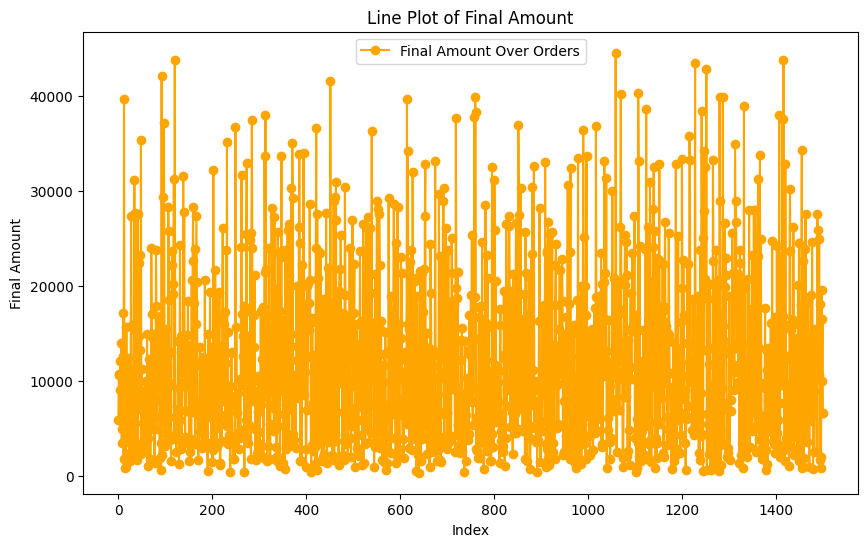

In [38]:
#line plot
plt.figure(figsize=(10,6))
plt.plot(df['FinalAmount'], color='orange', marker='o', label='Final Amount Over Orders')
plt.title('Line Plot of Final Amount')
plt.xlabel('Index')
plt.ylabel('Final Amount')
plt.legend()
plt.show()

#### B) Numerical vs Categorical

##### 🔸Non-Visual

In [39]:
#Groupby product category and calculate average final amount
df.groupby('ProductCategory')['FinalAmount'].mean().reset_index().sort_values(by='FinalAmount', ascending=False)

,ProductCategory,FinalAmount
1,Clothing,12711.883119
3,Home,12149.158845
0,Beauty,12113.296405
2,Electronics,11631.428669
4,Sports,11189.004313


In [40]:
#Groupby product category and calculate average Quantity
df.groupby('ProductCategory')['Quantity'].mean().reset_index().sort_values(by='Quantity', ascending=False)

,ProductCategory,Quantity
1,Clothing,5.266881
3,Home,5.234657
0,Beauty,5.032680
2,Electronics,4.965870
4,Sports,4.923323


In [41]:
#Groupby payment method and calculate total final amount
df.groupby('PaymentMethod')['FinalAmount'].sum().reset_index().sort_values(by='FinalAmount', ascending=False)

,PaymentMethod,FinalAmount
2,Debit Card,4745950.40
1,Credit Card,4625671.05
0,Cash,4506469.45
3,UPI,4057457.40


##### 🔸Visual

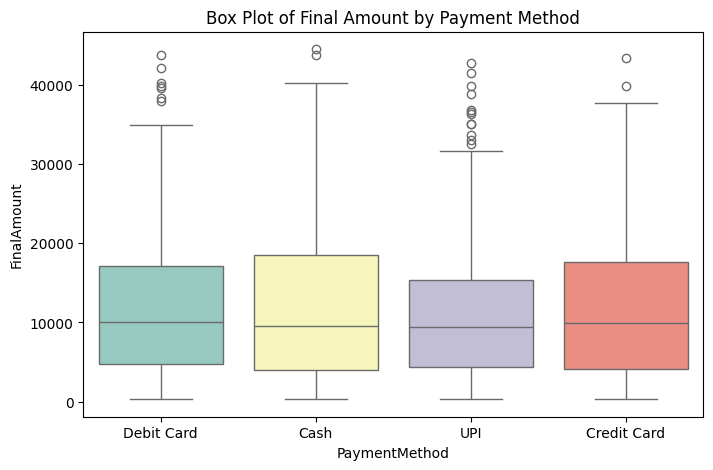

In [42]:
#box plot using seaborn
plt.figure(figsize=(8,5))
sns.boxplot(x='PaymentMethod', y='FinalAmount',hue='PaymentMethod' ,data=df, palette='Set3')
plt.title('Box Plot of Final Amount by Payment Method')
plt.show() 

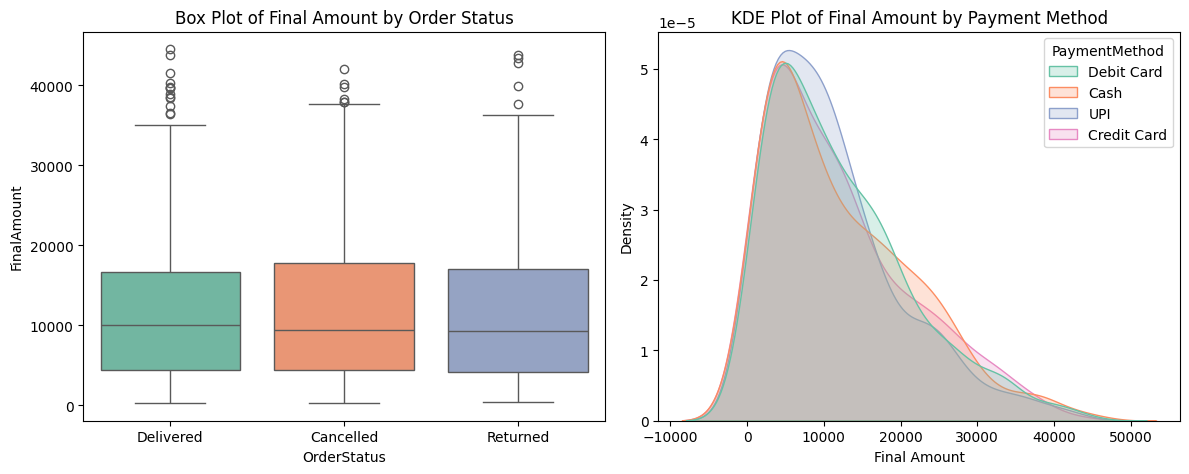

In [43]:
#box plot using seaborn
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x='OrderStatus', y='FinalAmount', hue='OrderStatus', data=df, palette='Set2')
plt.title('Box Plot of Final Amount by Order Status')

plt.subplot(1,2,2)
# KDE requires a numeric x; plot FinalAmount distributions by PaymentMethod using hue
sns.kdeplot(data=df, x='FinalAmount', hue='PaymentMethod', palette='Set2', common_norm=False, fill=True)
plt.title('KDE Plot of Final Amount by Payment Method')
plt.xlabel('Final Amount')
plt.tight_layout()
plt.show()

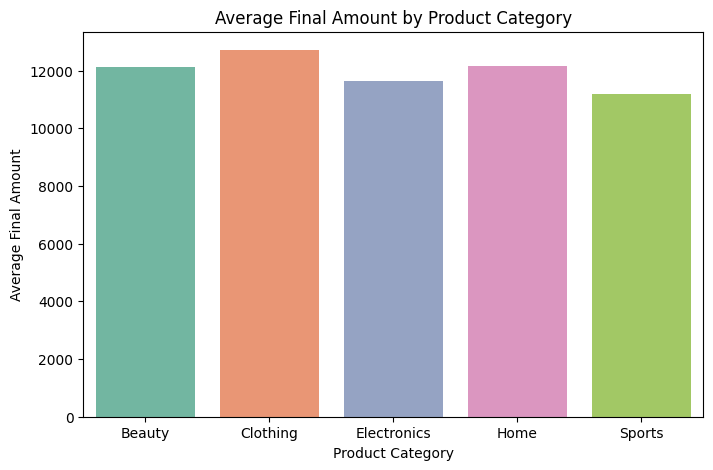

In [44]:
#bar plot of average Final Amount by Product Categor
avg_final_amount = df.groupby('ProductCategory')['FinalAmount'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='ProductCategory', y='FinalAmount', hue='ProductCategory', data=avg_final_amount, palette='Set2')
plt.title('Average Final Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Final Amount')
plt.show()

#### C) Categorical vs Categorical

##### 🔸Non-Visual

In [45]:
#crrosstabulation of Order Status and Payment Method
order_payment_crosstab = pd.crosstab(df['OrderStatus'], df['PaymentMethod'])
print(order_payment_crosstab)

PaymentMethod  Cash  Credit Card  Debit Card  UPI
OrderStatus                                      
Cancelled       135          120         126  121
Delivered       124          134         153  121
Returned        107          130         111  118


In [46]:
#crosstabulation of Product Category and Order Status
product_order_crosstab = pd.crosstab(df['ProductCategory'], df['OrderStatus'])
print(product_order_crosstab)

OrderStatus      Cancelled  Delivered  Returned
ProductCategory                                
Beauty                 110        104        92
Clothing               109        101       101
Electronics             93        115        85
Home                    95         97        85
Sports                  95        115       103


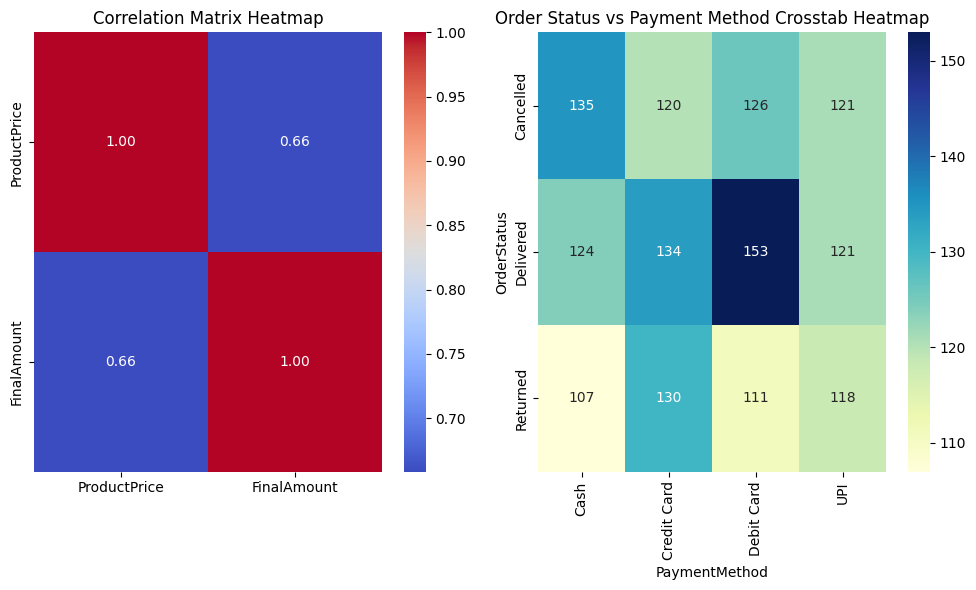

In [47]:
#heatmap of correlation matrix
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.heatmap(df[['ProductPrice', 'FinalAmount']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')

plt.subplot(1,2,2)
sns.heatmap(order_payment_crosstab, annot=True, cmap='YlGnBu', fmt="d")
plt.title('Order Status vs Payment Method Crosstab Heatmap')
plt.tight_layout()
plt.show()

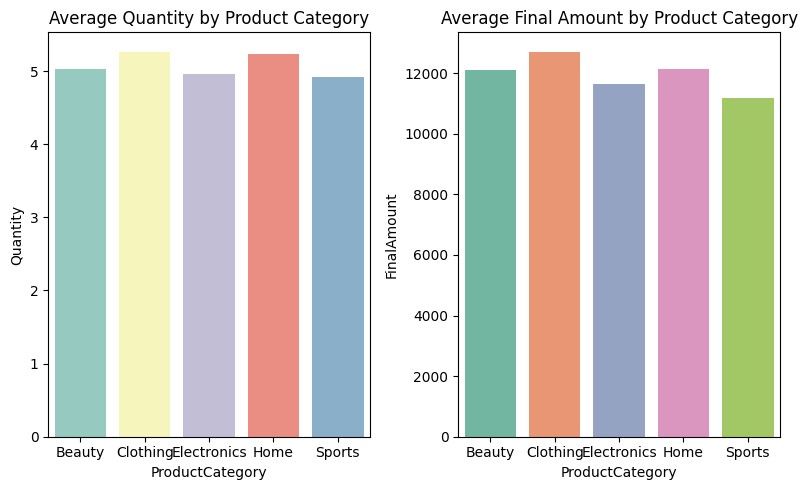

In [48]:
#bar plot of average Quantity by Product Category
avg_quantity = df.groupby('ProductCategory')['Quantity'].mean().reset_index()
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
sns.barplot(x='ProductCategory', y='Quantity', hue='ProductCategory', data=avg_quantity, palette='Set3')
plt.title('Average Quantity by Product Category')

plt.subplot(1,2,2)
# Use a bar plot instead of kdeplot for categorical x
sns.barplot(x='ProductCategory', y='FinalAmount', hue='ProductCategory', data=avg_final_amount, palette='Set2')
plt.title('Average Final Amount by Product Category')
plt.tight_layout()
plt.show()
